<a href="https://colab.research.google.com/github/faisu6339-glitch/Real_World-Projects/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('amazon.csv')

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,NaN,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",NaN,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",NaN,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4,NaN,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,NaN,NaN
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",NaN,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",NaN,"R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",NaN,"Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,NaN,NaN,4.2,NaN,The boAt Deuce USB 300 2 in 1 cable is compati...,NaN,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,NaN,NaN,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",NaN,"Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1283 non-null   object
 1   product_name         1375 non-null   object
 2   category             1105 non-null   object
 3   discounted_price     1145 non-null   object
 4   actual_price         1127 non-null   object
 5   discount_percentage  1190 non-null   object
 6   rating               1131 non-null   object
 7   rating_count         1234 non-null   object
 8   about_product        1390 non-null   object
 9   user_id              1257 non-null   object
 10  user_name            1199 non-null   object
 11  review_id            1329 non-null   object
 12  review_title         1153 non-null   object
 13  review_content       1353 non-null   object
 14  img_link             1161 non-null   object
 15  product_link         1234 non-null   object
dtypes: obj

In [ ]:
df.isnull().sum()

,0
product_id,182
product_name,90
category,360
discounted_price,320
actual_price,338
discount_percentage,275
rating,334
rating_count,231
about_product,75
user_id,208


In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
category,24.573379
actual_price,23.071672
rating,22.798635
discounted_price,21.843003
review_title,21.296928
img_link,20.750853
discount_percentage,18.771331
user_name,18.156997
rating_count,15.767918
product_link,15.767918


#Handling Missing Values

Cleaning Unwanted symbols

In [ ]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)

df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

In [ ]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

In [ ]:
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

In [ ]:
#df['rating'] = df['rating'].astype(float)

num_cols and cat_cols

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(num_cols)

Index(['discounted_price', 'actual_price', 'discount_percentage',
       'rating_count'],
      dtype='object')


In [ ]:
print(cat_cols)

Index(['product_id', 'product_name', 'category', 'rating', 'about_product',
       'user_id', 'user_name', 'review_id', 'review_title', 'review_content',
       'img_link', 'product_link'],
      dtype='object')


#Handling Num_Cols

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns


In [ ]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
    print(f'Missing values in {col}: {df[col].isnull().sum()}')

Missing values in discounted_price: 0
Missing values in actual_price: 0
Missing values in discount_percentage: 0
Missing values in rating_count: 0


/tmp/ipykernel_1914/3790392007.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#Handling Cat_Cols

In [ ]:
for col in cat_cols:
  df[col].fillna(df[col].mode()[0], inplace=True)
  print(f'Missing values in {col}: {df[col].isnull().sum()}')

Missing values in product_id: 0
Missing values in product_name: 0
Missing values in category: 0
Missing values in rating: 0
Missing values in about_product: 0
Missing values in user_id: 0
Missing values in user_name: 0
Missing values in review_id: 0
Missing values in review_title: 0
Missing values in review_content: 0
Missing values in img_link: 0
Missing values in product_link: 0


/tmp/ipykernel_1914/4160978764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


#Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
"""num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])"""

"num_pipeline = Pipeline([\n    ('imputer', SimpleImputer(strategy='median')),\n    ('scaler', StandardScaler())\n])"

In [ ]:
"""cat_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])"""

"cat_pipline = Pipeline([\n    ('imputer', SimpleImputer(strategy='most_frequent')),\n    ('encoder', OneHotEncoder(handle_unknown='ignore'))\n])"

In [ ]:
"""preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipline, cat_cols)
])"""

"preprocessor = ColumnTransformer([\n    ('num', num_pipeline, num_cols),\n    ('cat', cat_pipline, cat_cols)\n])"

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
product_id,0.0
product_name,0.0
category,0.0
discounted_price,0.0
actual_price,0.0
discount_percentage,0.0
rating,0.0
rating_count,0.0
about_product,0.0
user_id,0.0


#Outliers

In [ ]:
outliers_dict = {}

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers_dict[col] = df[(df[col] < lower) | (df[col] > upper)][col]

In [ ]:
print(outliers_dict)

{'discounted_price': 16      1.760996
24      1.373818
26      1.915868
38      4.703552
41      2.690224
          ...   
1416    0.367154
1428    0.540765
1432    0.522026
1438    0.644529
1455    0.133108
Name: discounted_price, Length: 200, dtype: float64, 'actual_price': 19      1.829042
24      1.619790
26      1.620732
38      4.341000
41      3.190117
          ...   
1416    2.143860
1428    0.372966
1430    2.666989
1432    0.730995
1438    0.678682
Name: actual_price, Length: 219, dtype: float64, 'discount_percentage': 33     -2.509649
138    -2.509649
321    -2.509649
340    -2.509649
406    -2.509649
466    -2.509649
498    -2.301836
539    -2.509649
616    -2.509649
637    -2.509649
695     2.373967
696    -2.301836
703    -2.509649
710    -2.509649
757    -2.509649
808    -2.509649
826    -2.509649
833    -2.509649
837    -2.509649
850    -2.509649
854    -2.509649
868    -2.405742
887    -2.509649
888    -2.509649
893    -2.509649
950    -2.509649
975    -2.509649
984  

In [ ]:
for col in num_cols:
    print(col, len(outliers_dict[col]))

discounted_price 200
actual_price 219
discount_percentage 47
rating_count 151


Capping

In [ ]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)

#Handling Messy data

#1.Category (1)

In [ ]:
# Split safely
cat_split = df['category'].str.split('|', expand=True)

# Assign columns dynamically
df['main_category'] = cat_split[0]
df['sub_category'] = cat_split[1]
df['sub_sub_category'] = cat_split[2]

In [ ]:
df[['category', 'main_category', 'sub_category', 'sub_sub_category']].head()

,category,main_category,sub_category,sub_sub_category
0,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
1,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
2,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
3,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories
4,Computers&Accessories|Accessories&Peripherals|...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories


In [ ]:
df['category'].sort_values(ascending=False).head()

,category
924,Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...
850,OfficeProducts|OfficePaperProducts|Paper|Stati...
955,OfficeProducts|OfficePaperProducts|Paper|Stati...
858,OfficeProducts|OfficePaperProducts|Paper|Stati...
1004,OfficeProducts|OfficePaperProducts|Paper|Stati...


#Handling Category Columns

In [ ]:
cat_split = df['category'].str.split('|', expand=True)

In [ ]:
cat_split.columns = [f'cat_level_{i}' for i in range(cat_split.shape[1])]

In [ ]:
df = pd.concat([df, cat_split], axis=1)

cat_Level_0

In [ ]:
df['cat_level_0'].value_counts()

,count
cat_level_0,
Computers&Accessories,695
Electronics,394
Home&Kitchen,347
OfficeProducts,23
HomeImprovement,2
MusicalInstruments,1
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


Cat_level_1

In [ ]:
df['cat_level_1'].value_counts()

,count
cat_level_1,
Accessories&Peripherals,643
Kitchen&HomeAppliances,243
Mobiles&Accessories,129
"HomeTheater,TV&Video",117
"Heating,Cooling&AirQuality",85
WearableTechnology,54
"Headphones,Earbuds&Accessories",48
NetworkingDevices,27
OfficePaperProducts,19


Cat_Level_2

In [ ]:
df['cat_level_2'].value_counts().head(10)

,count
cat_level_2,
Cables&Accessories,536
SmallKitchenAppliances,146
Accessories,66
MobileAccessories,66
Smartphones&BasicMobiles,63
"Vacuum,Cleaning&Ironing",62
Televisions,56
SmartWatches,54
Headphones,46


main_category

In [ ]:
df['main_category'].value_counts()

,count
main_category,
Computers&Accessories,695
Electronics,394
Home&Kitchen,347
OfficeProducts,23
HomeImprovement,2
MusicalInstruments,1
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


<Axes: xlabel='main_category'>

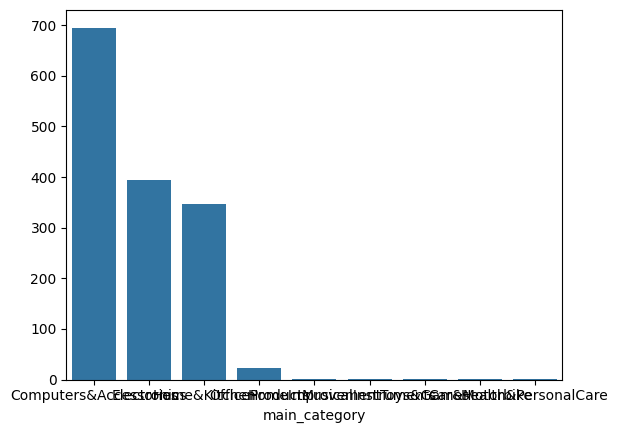

In [ ]:
import seaborn as sns
sns.barplot(
    x=df['main_category'].value_counts().index,
    y=df['main_category'].value_counts().values
)

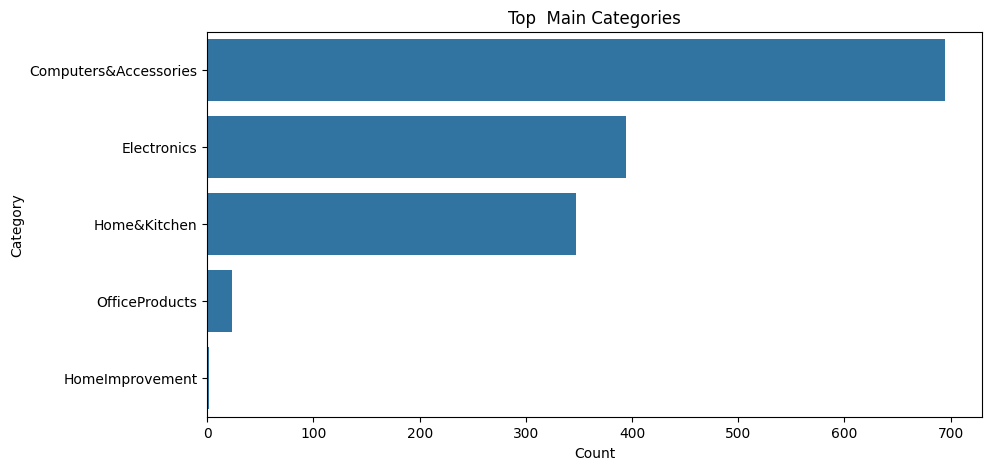

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_cat = df['main_category'].value_counts().head()

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title("Top  Main Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

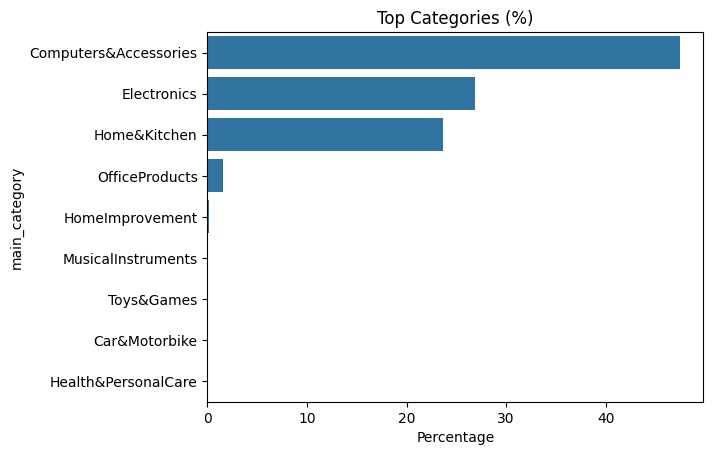

In [ ]:
top_cat = df['main_category'].value_counts(normalize=True).head(10) * 100

sns.barplot(x=top_cat.values, y=top_cat.index)

plt.title("Top Categories (%)")
plt.xlabel("Percentage")
plt.show()

sub_category

In [ ]:
df['sub_category'].value_counts()

,count
sub_category,
Accessories&Peripherals,643
Kitchen&HomeAppliances,243
Mobiles&Accessories,129
"HomeTheater,TV&Video",117
"Heating,Cooling&AirQuality",85
WearableTechnology,54
"Headphones,Earbuds&Accessories",48
NetworkingDevices,27
OfficePaperProducts,19


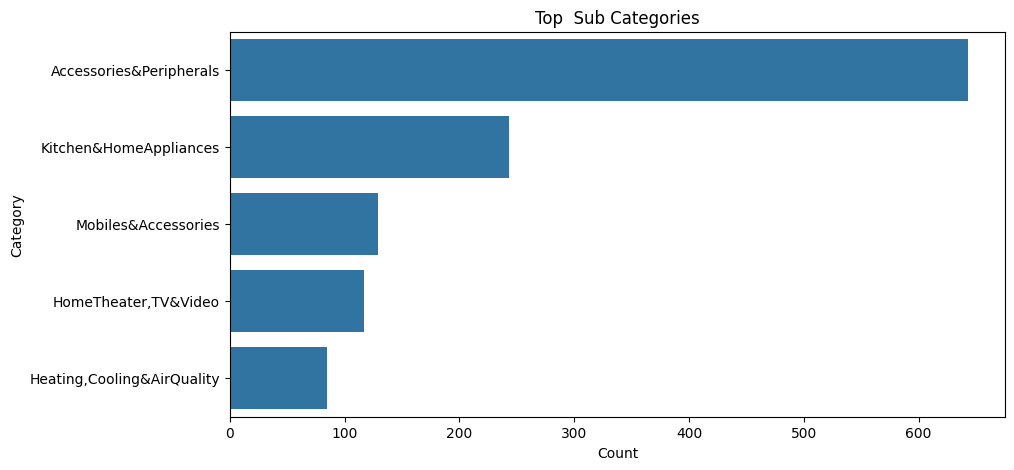

In [ ]:
top_cat = df['sub_category'].value_counts().head()

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title("Top  Sub Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

sub_sub_category

In [ ]:
df['sub_sub_category'].value_counts()

,count
sub_sub_category,
Cables&Accessories,536
SmallKitchenAppliances,146
Accessories,66
MobileAccessories,66
Smartphones&BasicMobiles,63
...,...
HardDriveAccessories,1
TraditionalLaptops,1
InteriorAccessories,1


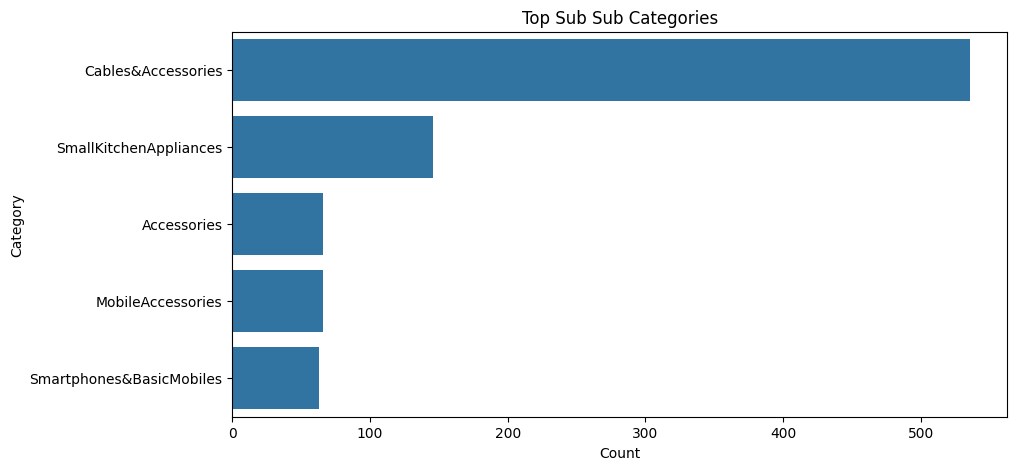

In [ ]:
top_cat = df['sub_sub_category'].value_counts().head()

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title("Top Sub Sub Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

#Univariate Analysis

In [ ]:
df[num_cols] = scaler.inverse_transform(df[num_cols])

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,main_category,sub_category,sub_sub_category,cat_level_0,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5,cat_level_6
0,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4,5367.5,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,50.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,1650.0,50.0,4.2,5367.5,The boAt Deuce USB 300 2 in 1 cable is compati...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,50.0,4.1,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None


In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'main_category',
       'sub_category', 'sub_sub_category', 'cat_level_0', 'cat_level_1',
       'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5',
       'cat_level_6'],
      dtype='object')

In [ ]:
num_cols

Index(['discounted_price', 'actual_price', 'discount_percentage',
       'rating_count'],
      dtype='object')

In [ ]:
df[num_cols].describe()

,discounted_price,actual_price,discount_percentage,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000
mean,1165.303072,2328.089843,48.443686,9739.714334
std,1008.866648,1886.289320,18.920448,10646.680490
min,39.000000,39.000000,5.000000,2.000000
25%,399.000000,999.000000,38.000000,1662.000000
50%,799.000000,1650.000000,50.000000,5367.500000
75%,1529.000000,2999.000000,60.000000,14120.000000
max,3224.000000,5999.000000,93.000000,32807.000000


#Numeric Columns

In [ ]:
for col in num_cols:
    print(f"\n🔹 Sorted values for {col} (Top 5):")
    print(df[col].sort_values(ascending=False).head())


🔹 Sorted values for discounted_price (Top 5):
1438    3224.0
1432    3224.0
1416    3224.0
1428    3224.0
26      3224.0
Name: discounted_price, dtype: float64

🔹 Sorted values for actual_price (Top 5):
336     5999.0
1438    5999.0
338     5999.0
1432    5999.0
1430    5999.0
Name: actual_price, dtype: float64

🔹 Sorted values for discount_percentage (Top 5):
695    93.0
368    91.0
334    91.0
372    91.0
380    91.0
Name: discount_percentage, dtype: float64

🔹 Sorted values for rating_count (Top 5):
30      32807.0
17      32807.0
16      32807.0
1145    32807.0
1130    32807.0
Name: rating_count, dtype: float64


#highlight top 10 expensive products

In [ ]:
df['discounted_price'] = df['discounted_price'].astype(float)

In [ ]:
top_10_expensive = df.sort_values(by='discounted_price', ascending=False).head(10)

top_10_expensive[['product_name', 'discounted_price', 'actual_price', 'rating']]

,product_name,discounted_price,actual_price,rating
1438,INALSA Air Fryer Digital 4L Nutri Fry - 1400W ...,3224.0,5999.0,4.5
1432,AGARO Royal Stand 1000W Mixer with 5L SS Bowl ...,3224.0,5999.0,4.1
1416,Aqua d pure Active Copper 12-L RO+UV Water Fil...,3224.0,5999.0,4.1
1428,"Sujata Dynamix, Mixer Grinder, 900 Watts, 3 Ja...",3224.0,5999.0,4.6
26,OnePlus 80 cm (32 inches) Y Series HD Ready LE...,3224.0,5999.0,4.2
24,Acer 80 cm (32 inches) I Series HD Ready Andro...,3224.0,5999.0,4.3
1410,"Sujata Supermix, Mixer Grinder, 900 Watts, 3 J...",3224.0,5999.0,4.1
1404,Maharaja Whiteline Odacio Plus 550-Watt Juicer...,3224.0,4799.0,4.1
1405,Shakti Technology S3 High Pressure Car Washer ...,3224.0,1650.0,4.1
1407,"AGARO Glory Cool Mist Ultrasonic Humidifier, 4...",3224.0,5799.0,4.1


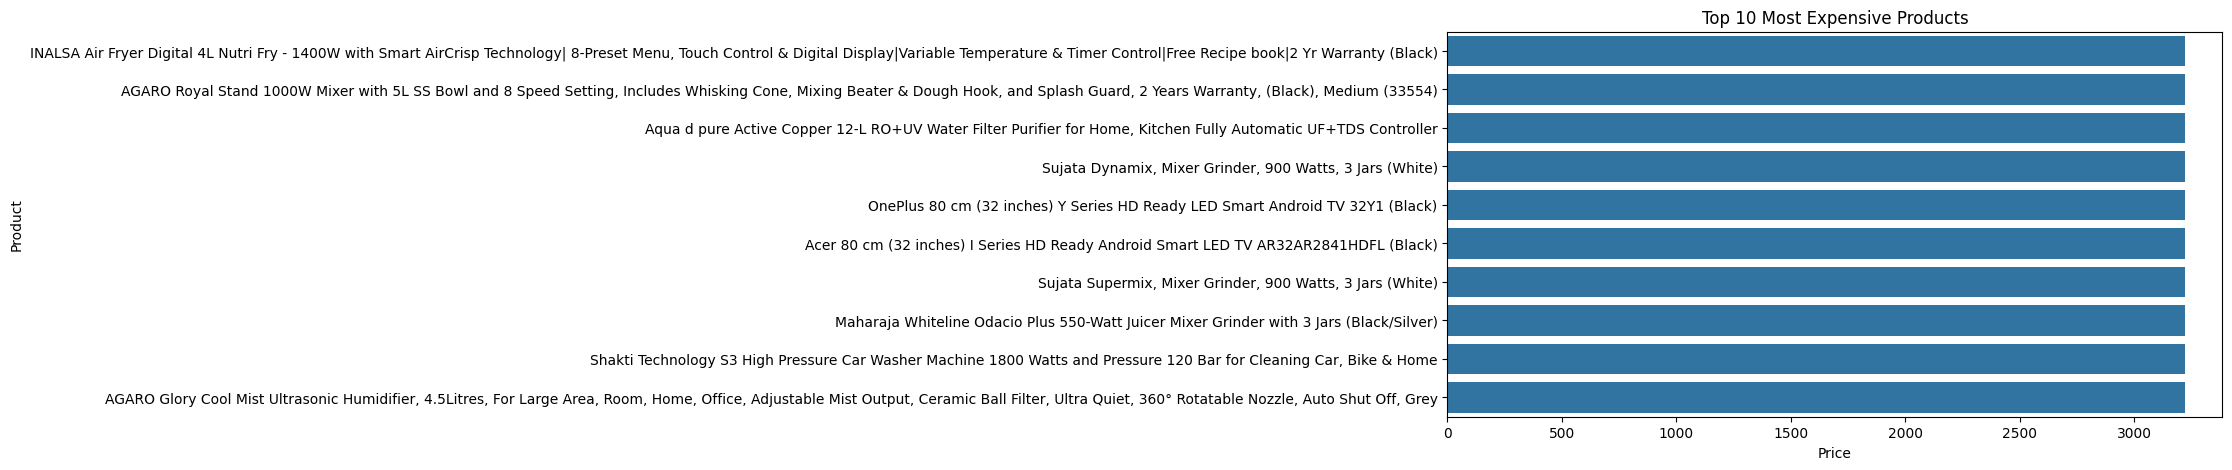

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_10_expensive['discounted_price'],
    y=top_10_expensive['product_name']
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Price")
plt.ylabel("Product")
plt.show()

In [ ]:
top_10_expensive['discount'] = (
    (top_10_expensive['actual_price'] - top_10_expensive['discounted_price'])
    / top_10_expensive['actual_price']
) * 100

print(top_10_expensive[['product_name', 'discount']])

                                           product_name   discount
1438  INALSA Air Fryer Digital 4L Nutri Fry - 1400W ...  46.257710
1432  AGARO Royal Stand 1000W Mixer with 5L SS Bowl ...  46.257710
1416  Aqua d pure Active Copper 12-L RO+UV Water Fil...  46.257710
1428  Sujata Dynamix, Mixer Grinder, 900 Watts, 3 Ja...  46.257710
26    OnePlus 80 cm (32 inches) Y Series HD Ready LE...  46.257710
24    Acer 80 cm (32 inches) I Series HD Ready Andro...  46.257710
1410  Sujata Supermix, Mixer Grinder, 900 Watts, 3 J...  46.257710
1404  Maharaja Whiteline Odacio Plus 550-Watt Juicer...  32.819337
1405  Shakti Technology S3 High Pressure Car Washer ... -95.393939
1407  AGARO Glory Cool Mist Ultrasonic Humidifier, 4...  44.404208


#Top 10 discount products

In [ ]:
top_discount=df.sort_values(by='discount_percentage',ascending=False).head(10)
top_discount[['product_name','discount_percentage']]

,product_name,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",93.0
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
920,"Silicone Rubber Earbuds Tips, Eartips, Earpads...",90.0
602,LAPSTER Spiral Charger Spiral Charger Cable Pr...,90.0
1026,beatXP Kitchen Scale Multipurpose Portable Ele...,90.0
644,Sounce Spiral Charger Cable Protector Data Cab...,90.0
542,Sounce Protective Case Cover Compatible Boat X...,90.0


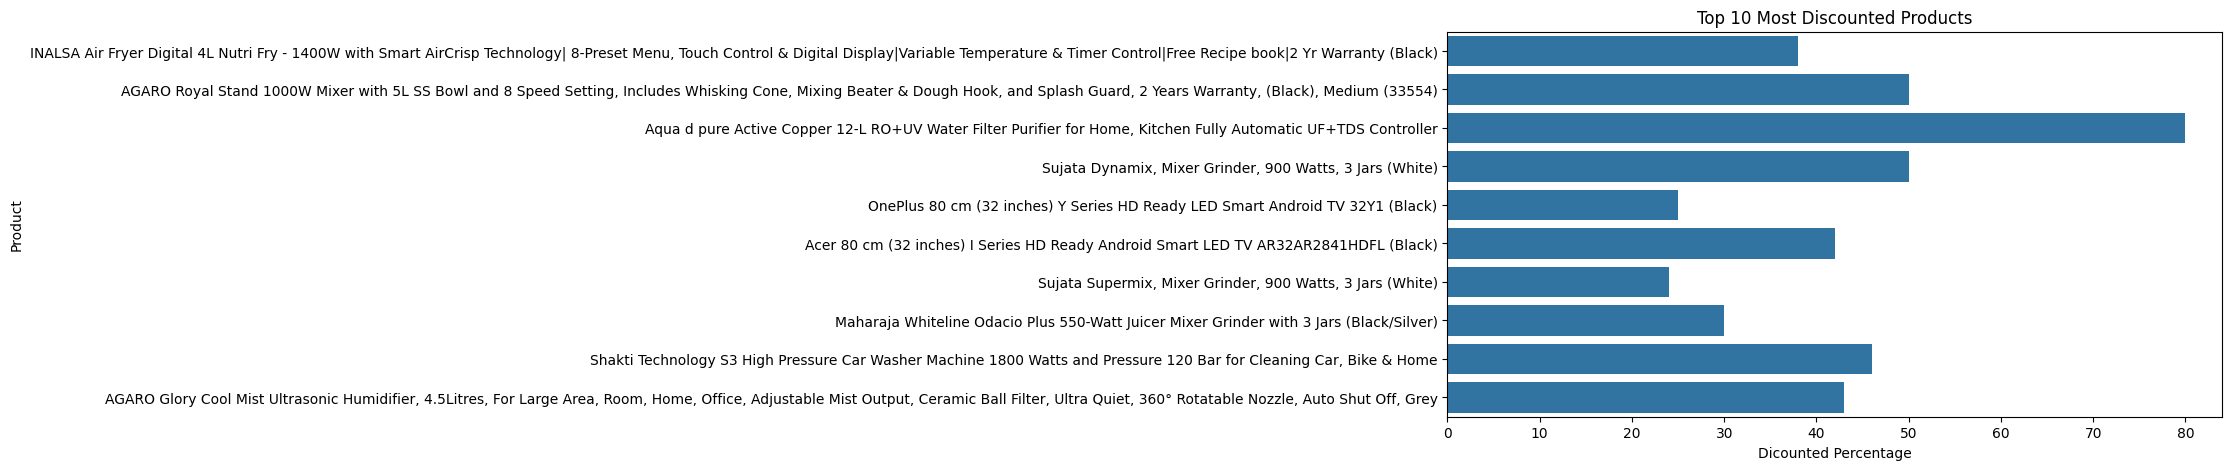

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_10_expensive['discount_percentage'],
    y=top_10_expensive['product_name']
)

plt.title("Top 10 Most Discounted Products")
plt.xlabel("Dicounted Percentage")
plt.ylabel("Product")
plt.show()

#Best Deals

In [ ]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [ ]:
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

In [ ]:
best_deals = df[
    (df['discount_percentage'] > 50) &
    (df['rating'] >= 4.5)
].sort_values(by='discount_percentage', ascending=False)

best_deals[['product_name', 'discount_percentage', 'rating']].head(10)

,product_name,discount_percentage,rating
174,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",80.0,5.0
1289,Aquadpure Copper + Mineral RO+UV+UF 10 to 12 L...,80.0,4.6
1018,Lapster 65W compatible for OnePlus Dash Warp C...,80.0,4.5
580,Elv Aluminium Adjustable Mobile Phone Foldable...,79.0,4.5
520,Kyosei Advanced Tempered Glass Compatible with...,75.0,4.5
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",75.0,5.0
30,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,73.0,4.5
802,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,73.0,4.5
852,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,70.0,4.5
40,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,70.0,4.5


#Lowest Price products

In [ ]:
lowest_price = df.sort_values(by='discounted_price', ascending=True).head(10)

lowest_price[['product_name', 'discounted_price', 'actual_price', 'rating']]

,product_name,discounted_price,actual_price,rating
975,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,39.00,39.0,3.8
997,Inventis 5V 1.2W Portable Flexible USB LED Lig...,39.00,39.0,3.6
178,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",57.89,199.0,4.1
478,Flix Micro Usb Cable For Smartphone (Black),59.00,199.0,4.1
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,59.00,199.0,4.1
727,Flix Micro Usb Cable For Smartphone (Black),59.00,1650.0,4.0
710,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,59.00,1650.0,4.1
798,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",69.00,299.0,4.3
521,STRIFF 12 Pieces Highly Flexible Silicone Micr...,79.00,499.0,4.2
1395,Empty Mist Trigger Plastic Spray Bottle for Mu...,85.00,1650.0,4.1


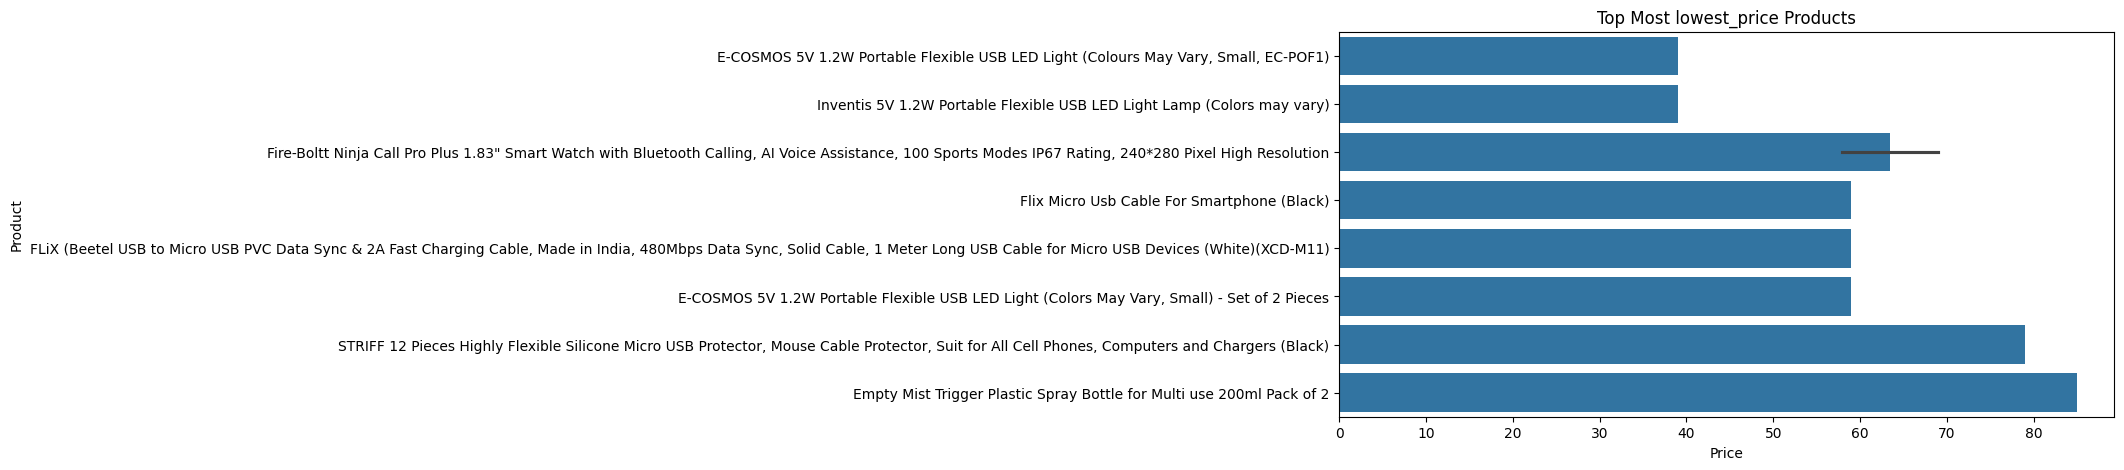

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=lowest_price['discounted_price'],
    y=lowest_price['product_name']
)

plt.title("Top Most lowest_price Products")
plt.xlabel("Price")
plt.ylabel("Product")
plt.show()

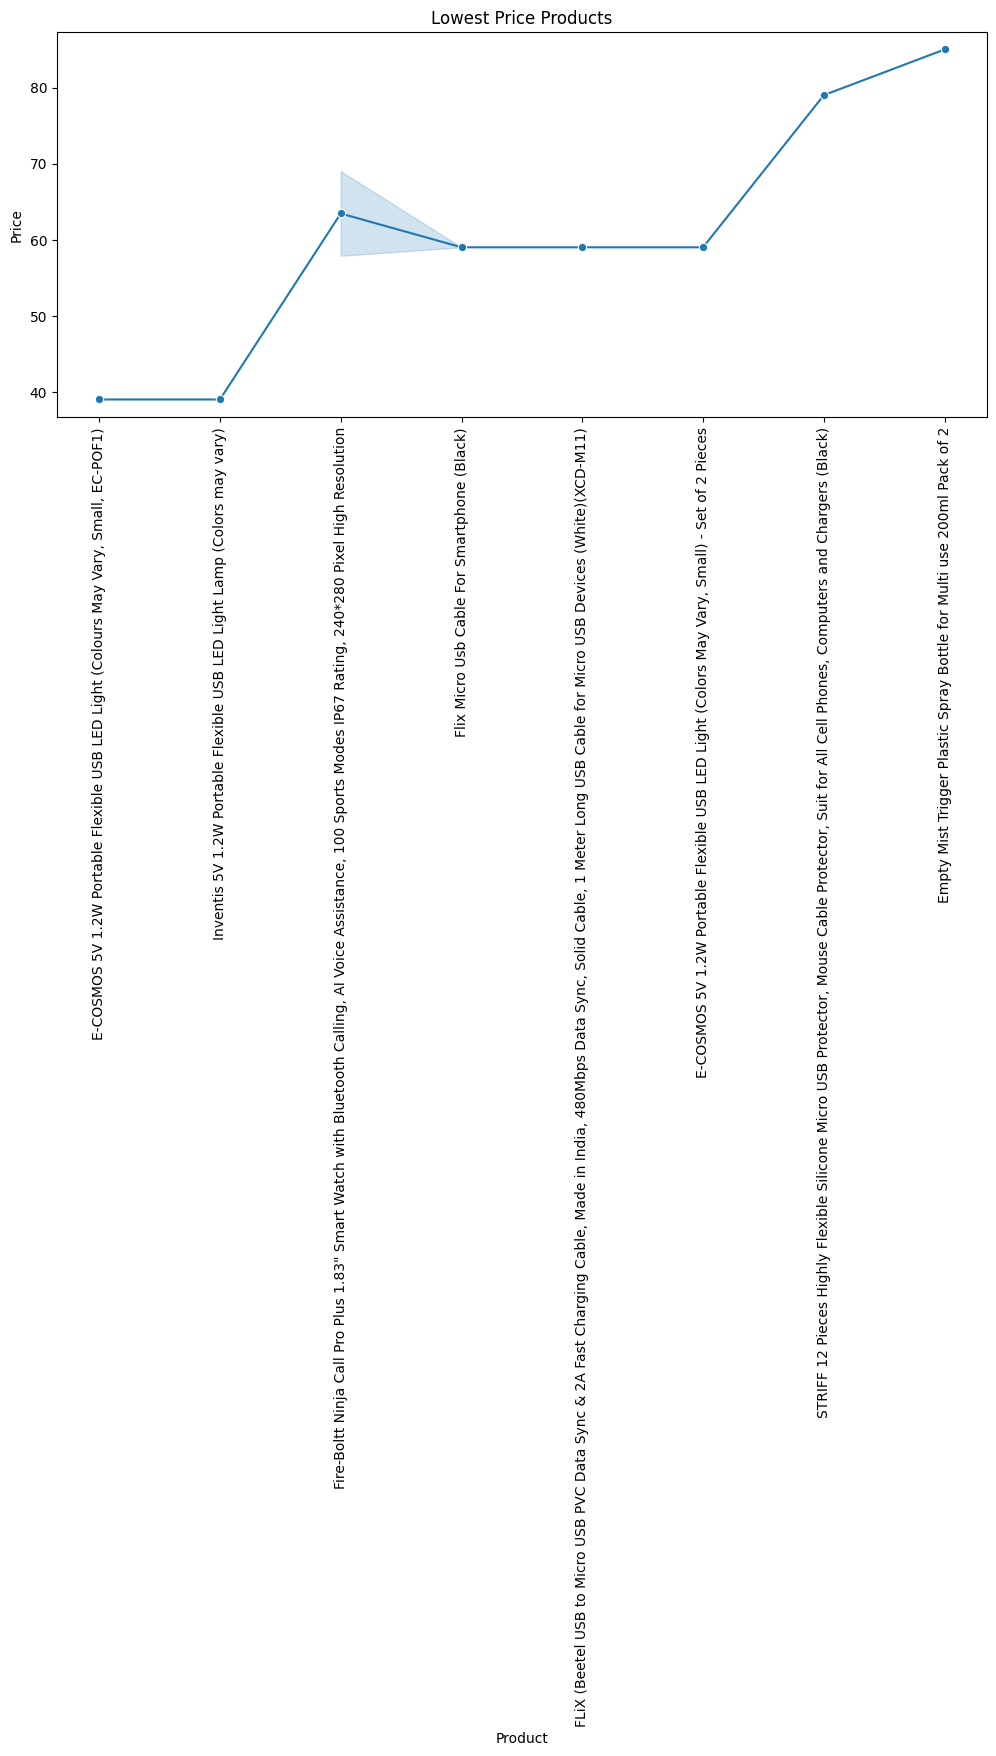

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=lowest_price['product_name'],
    y=lowest_price['discounted_price'],
    marker='o'
)

plt.xticks(rotation=90)  # rotate names
plt.title("Lowest Price Products")
plt.xlabel("Product")
plt.ylabel("Price")
plt.show()

In [ ]:
df['rating'].sort_values(ascending=False).head()

,rating
324,5.0
174,5.0
1201,4.8
1145,4.8
1226,4.7


#Categorical Columns

In [ ]:
print(cat_cols)

Index(['product_id', 'product_name', 'category', 'rating', 'about_product',
       'user_id', 'user_name', 'review_id', 'review_title', 'review_content',
       'img_link', 'product_link'],
      dtype='object')


In [ ]:
for col in cat_cols:
    print(f"\n🔹 Sorted values for {col} (Top 5):")
    print(df[col].sort_values(ascending=False).head())


🔹 Sorted values for product_id (Top 5):
324     B0BQRJ3C47
1201    B0BQ3K23Y1
1194    B0BPCJM7TB
1080    B0BPBXNQQT
1436    B0BPBG712X
Name: product_id, dtype: object

🔹 Sorted values for product_name (Top 5):
722    tizum HDMI to VGA Adapter Cable 1080P for Proj...
21     tizum HDMI to VGA Adapter Cable 1080P for Proj...
695    rts [2 Pack] Mini USB C Type C Adapter Plug, T...
439    realme narzo 50i (Mint Green, 2GB RAM+32GB Sto...
383    realme narzo 50 (Speed Blue, 4GB RAM+64GB Stor...
Name: product_name, dtype: object

🔹 Sorted values for category (Top 5):
924     Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...
850     OfficeProducts|OfficePaperProducts|Paper|Stati...
955     OfficeProducts|OfficePaperProducts|Paper|Stati...
858     OfficeProducts|OfficePaperProducts|Paper|Stati...
1004    OfficeProducts|OfficePaperProducts|Paper|Stati...
Name: category, dtype: object

🔹 Sorted values for rating (Top 5):
324     5.0
174     5.0
1201    4.8
1145    4.8
1226    4.7
Name: rating, 

In [ ]:
df['category'].value_counts()

,count
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,530
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,57
Electronics|WearableTechnology|SmartWatches,54
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",50
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",37
...,...
"Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories",1
"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|RoboticVacuums",1
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|StandMixers,1


#👉 Remove useless cols:

In [ ]:
drop_cols = ['product_id', 'user_id', 'review_id', 'img_link', 'product_link']
df = df.drop(columns=drop_cols)

#Numerical vs Numerical

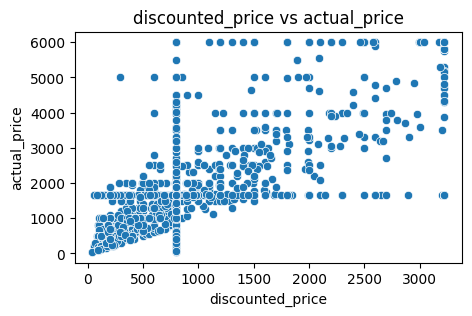

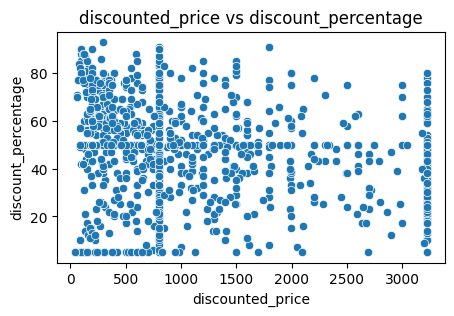

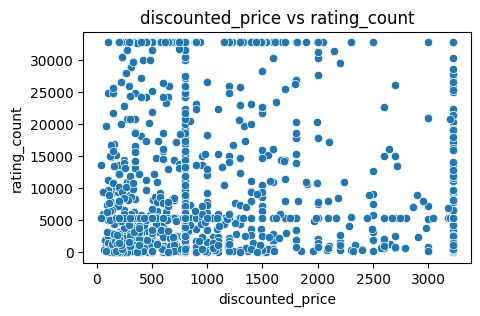

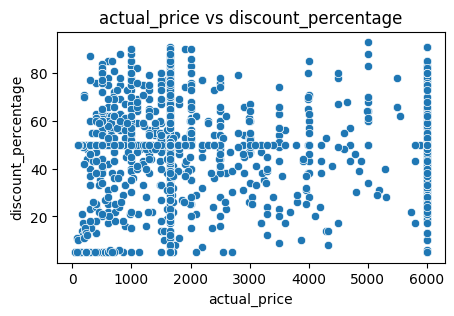

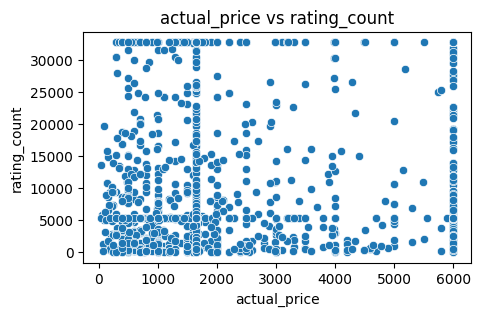

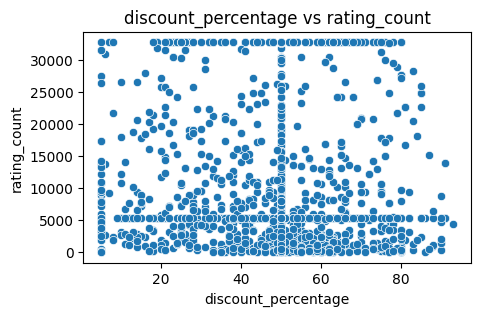

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        plt.figure(figsize=(5,3))
        sns.scatterplot(x=df[num_cols[i]], y=df[num_cols[j]])
        plt.title(f"{num_cols[i]} vs {num_cols[j]}")
        plt.show()

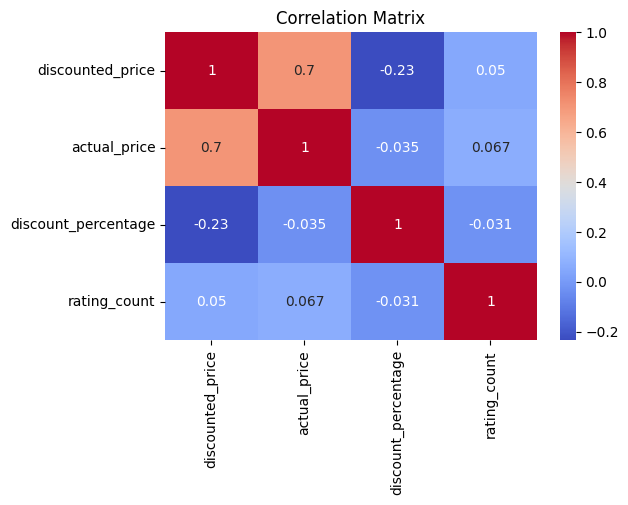

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

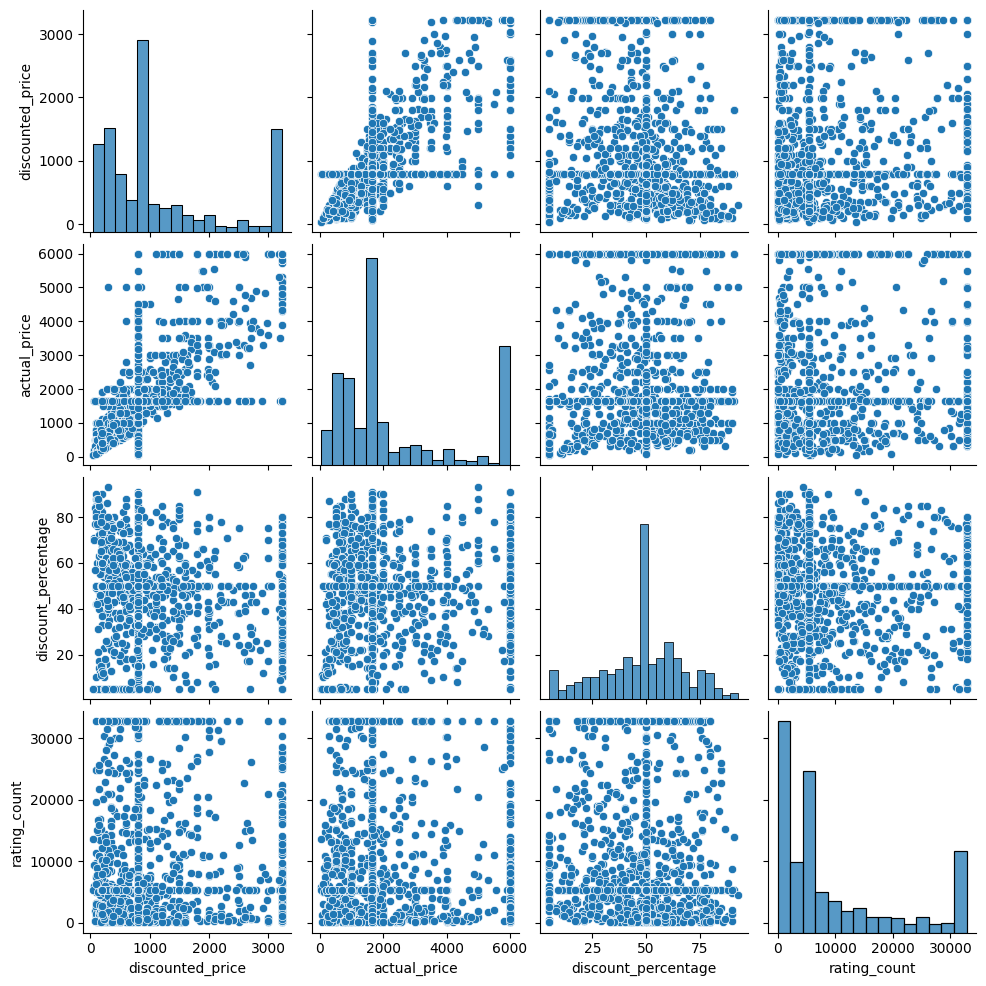

In [ ]:
sns.pairplot(df[num_cols])

#1.Price vs Rating

<Axes: xlabel='discounted_price', ylabel='rating'>

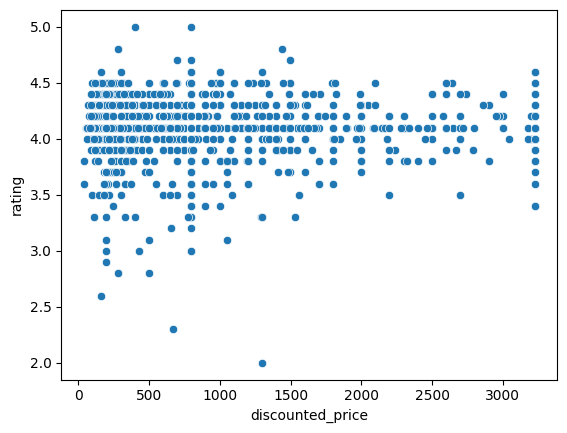

In [ ]:
sns.scatterplot(x=df['discounted_price'], y=df['rating'])

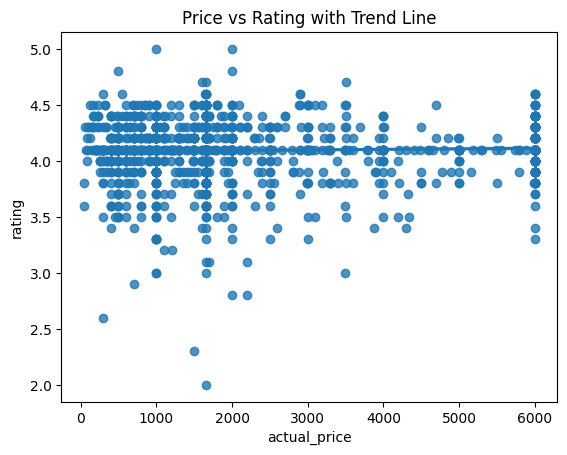

In [ ]:
sns.regplot(x='actual_price', y='rating', data=df)
plt.title("Price vs Rating with Trend Line")
plt.show()

<Axes: xlabel='rating', ylabel='discounted_price'>

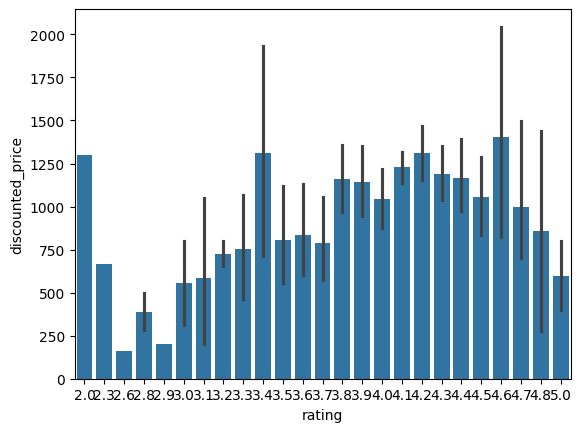

In [ ]:
sns.barplot(x=df['rating'], y=df['discounted_price'])

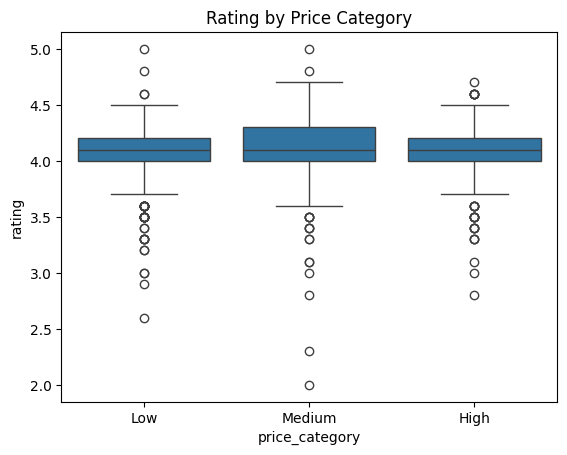

In [ ]:
df['price_category'] = pd.qcut(df['actual_price'], q=3, labels=['Low','Medium','High'])

sns.boxplot(x='price_category', y='rating', data=df)
plt.title("Rating by Price Category")
plt.show()

#2.Discount vs Rating

<Axes: xlabel='discount_percentage', ylabel='rating'>

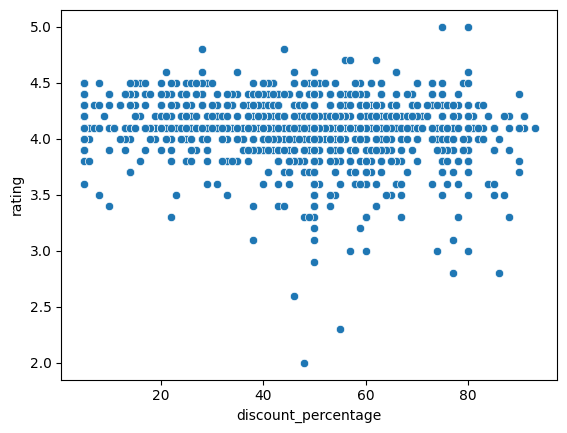

In [ ]:
sns.scatterplot(x=df['discount_percentage'], y=df['rating'])

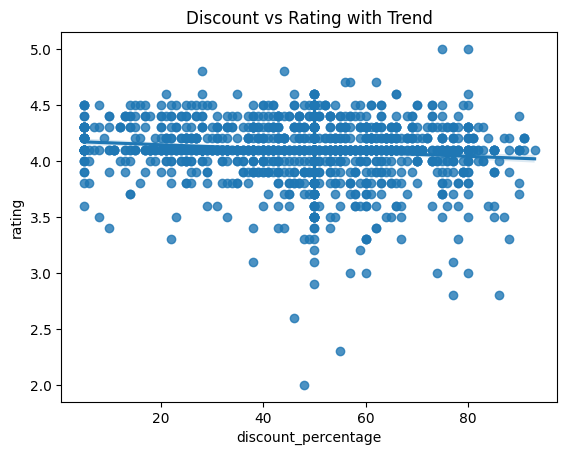

In [ ]:
sns.regplot(x='discount_percentage', y='rating', data=df)

plt.title("Discount vs Rating with Trend")
plt.show()

In [ ]:
df[['discount_percentage','rating']].corr()

,discount_percentage,rating
discount_percentage,1.000000,-0.125038
rating,-0.125038,1.000000


#3.✅ Price vs Discount


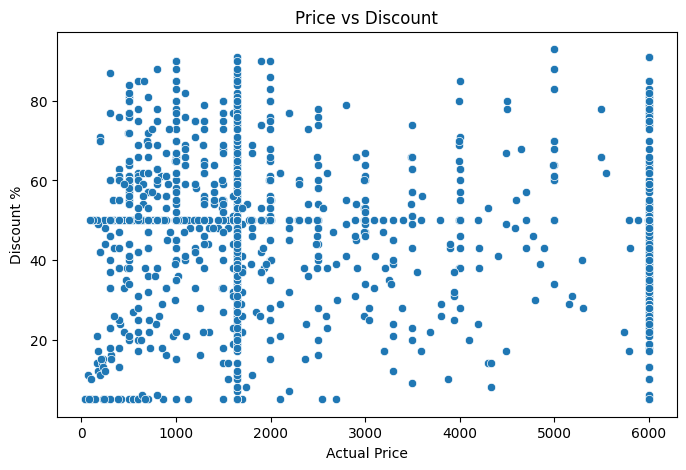

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='actual_price', y='discount_percentage', data=df)

plt.title("Price vs Discount")
plt.xlabel("Actual Price")
plt.ylabel("Discount %")
plt.show()

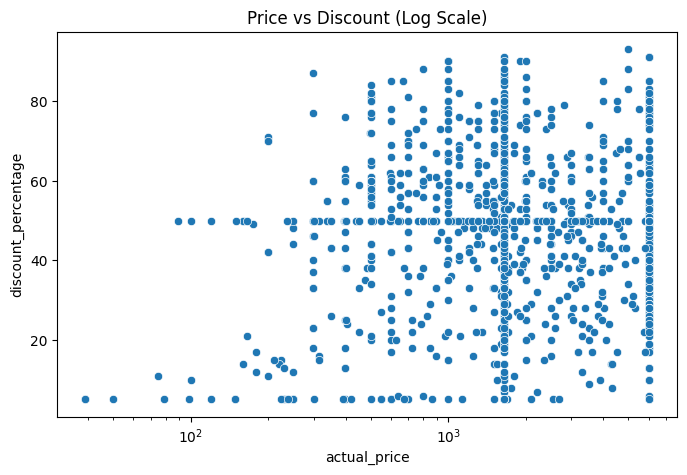

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='actual_price', y='discount_percentage', data=df)

plt.xscale('log')  # 🔥 important

plt.title("Price vs Discount (Log Scale)")
plt.show()

#Discount Amount

In [ ]:
df['discount_amount'] = df['actual_price'] - df['discounted_price']

<Axes: xlabel='actual_price', ylabel='discount_amount'>

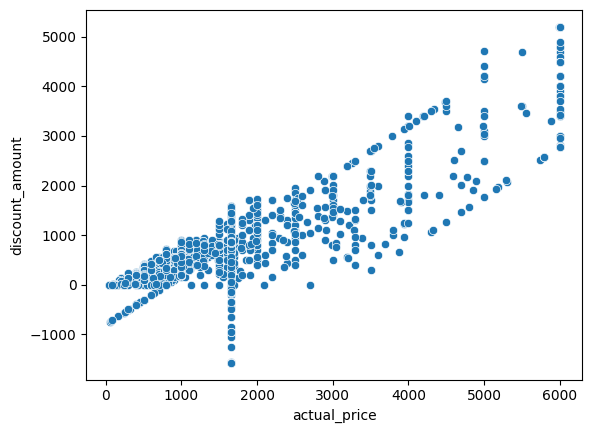

In [ ]:
sns.scatterplot(x='actual_price', y='discount_amount', data=df)

#4.Category vs Price

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Computers&Accessories'),
  Text(1, 0, 'Electronics'),
  Text(2, 0, 'MusicalInstruments'),
  Text(3, 0, 'Home&Kitchen'),
  Text(4, 0, 'OfficeProducts'),
  Text(5, 0, 'HomeImprovement'),
  Text(6, 0, 'Toys&Games'),
  Text(7, 0, 'Car&Motorbike'),
  Text(8, 0, 'Health&PersonalCare')])

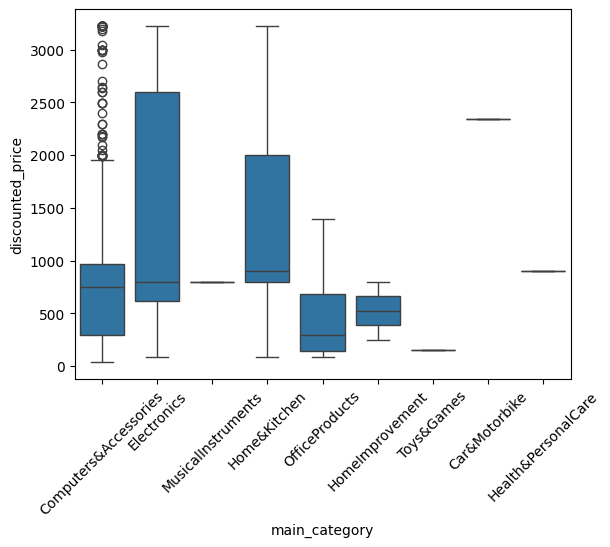

In [ ]:
sns.boxplot(x='main_category', y='discounted_price', data=df)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Computers&Accessories'),
  Text(1, 0, 'Electronics'),
  Text(2, 0, 'MusicalInstruments'),
  Text(3, 0, 'Home&Kitchen'),
  Text(4, 0, 'OfficeProducts'),
  Text(5, 0, 'HomeImprovement'),
  Text(6, 0, 'Toys&Games'),
  Text(7, 0, 'Car&Motorbike'),
  Text(8, 0, 'Health&PersonalCare')])

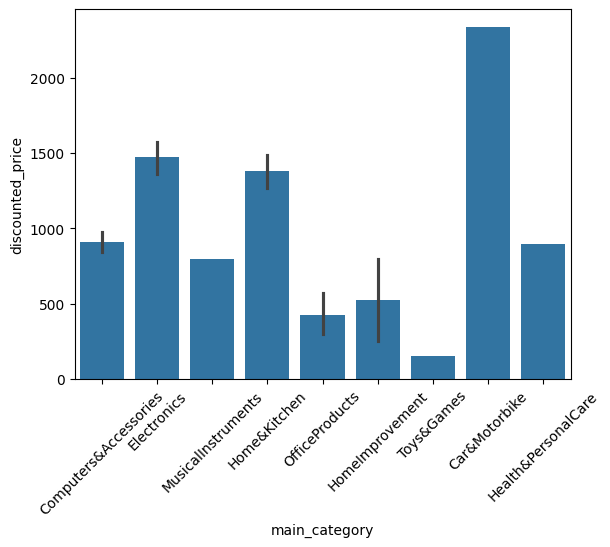

In [ ]:
sns.barplot(x='main_category', y='discounted_price', data=df)
plt.xticks(rotation=45)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Accessories&Peripherals'),
  Text(1, 0, 'NetworkingDevices'),
  Text(2, 0, 'HomeTheater,TV&Video'),
  Text(3, 0, 'HomeAudio'),
  Text(4, 0, 'WearableTechnology'),
  Text(5, 0, 'Mobiles&Accessories'),
  Text(6, 0, 'Headphones,Earbuds&Accessories'),
  Text(7, 0, 'Accessories'),
  Text(8, 0, 'ExternalDevices&DataStorage'),
  Text(9, 0, 'Microphones'),
  Text(10, 0, 'GeneralPurposeBatteries&BatteryChargers'),
  Text(11, 0, 'CraftMaterials'),
  Text(12, 0, 'Cameras&Photography'),
  Text(13, 0, 'OfficeElectronics'),
  Text(14, 0, 'Printers,Inks&Accessories'),
  Text(15, 0, 'OfficePaperProducts'),
  Text(16, 0, 'Electrical'),
  Text(17, 0, 'Components'),
  Text(18, 0, 'Monitors'),
  Text(19, 0, 'Arts&Crafts'),
  Text(20, 0, 'PowerAccessories'),
  Text(21, 0, 'Tablets'),
  Text(22, 0, 'Laptops'),
  Text(23, 0, 'Kitchen&Home

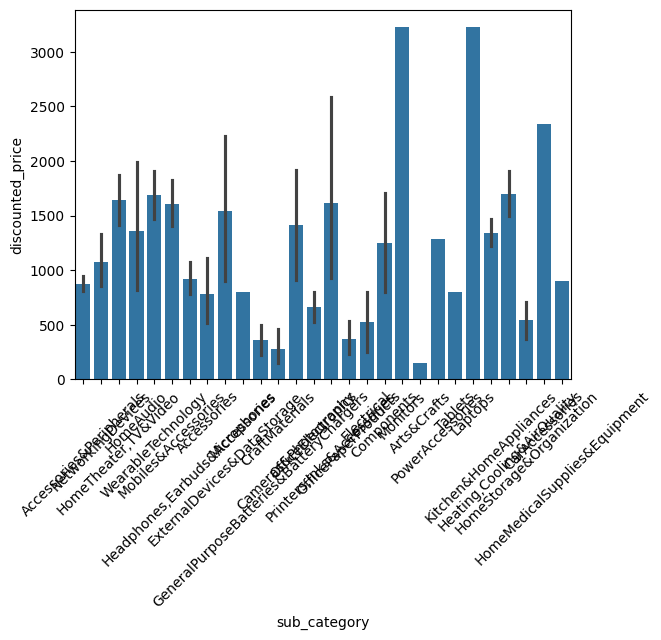

In [ ]:
sns.barplot(x='sub_category', y='discounted_price', data=df)
plt.xticks(rotation=45)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 [Text(0, 0, 'Cables&Accessories'),
  Text(1, 0, 'NetworkAdapters'),
  Text(2, 0, 'Accessories'),
  Text(3, 0, 'Televisions'),
  Text(4, 0, 'SatelliteEquipment'),
  Text(5, 0, 'MediaStreamingDevices'),
  Text(6, 0, 'Speakers'),
  Text(7, 0, 'Projectors'),
  Text(8, 0, 'SmartWatches'),
  Text(9, 0, 'Smartphones&BasicMobiles'),
  Text(10, 0, 'Headphones'),
  Text(11, 0, 'MobileAccessories'),
  Text(12, 0, 'MemoryCards'),
  Text(13, 0, 'LaptopAccessories'),
  Text(14, 0, 'Adapters'),
  Text(15, 0, 'Keyboards,Mice&InputDevices'),
  Text(16, 0, 'PenDrives'),
  Text(17, 0, 'Condenser'),
  Text(18, 0, 'DisposableBatter

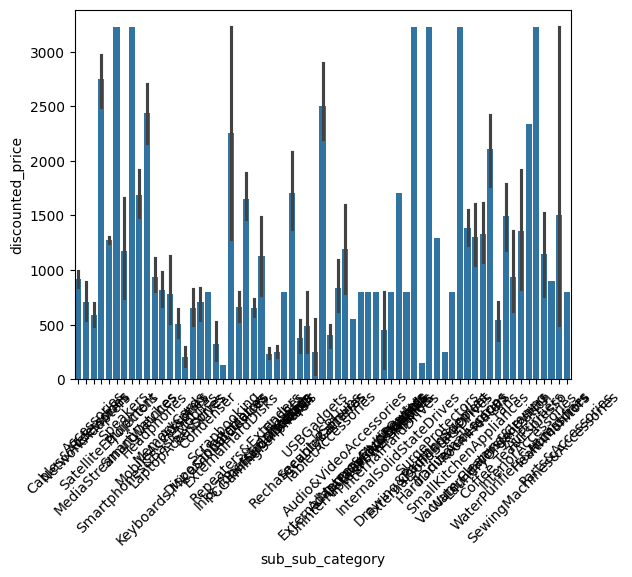

In [ ]:
sns.barplot(x='sub_sub_category', y='discounted_price', data=df)
plt.xticks(rotation=45)

#Handling Prices

In [ ]:
df['discount_ratio'] = df['discounted_price'] / df['actual_price']

In [ ]:
df['discount_ratio']

,discount_ratio
0,0.363057
1,0.570201
2,0.104792
3,0.199394
4,0.385965
...,...
1460,0.412405
1461,0.748768
1462,0.484242
1463,0.740212


In [ ]:
df['price_bucket'] = pd.cut(
    df['discounted_price'],
    bins=[0, 200, 500, 1000, 5000, 10000],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Premium']
)

In [ ]:
df['price_bucket'].value_counts()

,count
price_bucket,
Medium,526
High,497
Low,286
Very Low,156
Premium,0


In [ ]:
df['brand'] = df['product_name'].apply(lambda x: str(x).split()[0])

In [ ]:
df['brand'].value_counts()

,count
brand,
Fire-Boltt,116
boAt,63
Samsung,32
AmazonBasics,29
Portronics,29
...,...
Syska,1
Kitchengenix's,1
KNOWZA,1


In [ ]:
df['name_length'] = df['product_name'].astype(str).apply(len)

In [ ]:
df['name_length']

,name_length
0,153
1,193
2,136
3,199
4,110
...,...
1460,183
1461,55
1462,78
1463,54


In [ ]:
df['popularity_score'] = df['rating'] * df['rating_count']

In [ ]:
df['popularity_score'].value_counts()

,count
popularity_score,
22006.75,81
134508.70,53
23080.25,33
137789.40,32
22543.50,29
...,...
74.80,1
43801.80,1
5653.90,1


In [ ]:
df.columns

Index(['product_name', 'category', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'about_product',
       'user_name', 'review_title', 'review_content', 'main_category',
       'sub_category', 'sub_sub_category', 'cat_level_0', 'cat_level_1',
       'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5',
       'cat_level_6', 'price_category', 'discount_amount', 'discount_ratio',
       'price_bucket', 'brand', 'name_length', 'popularity_score'],
      dtype='object')

#Models For Predictions

In [ ]:
drop_cols = [
    'product_name',
    'category',
    'about_product',
    'review_content',
    'review_title',
    'user_name'
]

df = df.drop(columns=drop_cols)

In [ ]:
drop_cols2 = [
    'cat_level_0','cat_level_1','cat_level_2',
    'cat_level_3','cat_level_4','cat_level_5','cat_level_6'
]

df = df.drop(columns=drop_cols2)

In [ ]:
df.columns

Index(['discounted_price', 'actual_price', 'discount_percentage', 'rating',
       'rating_count', 'main_category', 'sub_category', 'sub_sub_category',
       'price_category', 'discount_amount', 'discount_ratio', 'price_bucket',
       'brand', 'name_length', 'popularity_score'],
      dtype='object')

In [ ]:
df['sales_estimate'] = df['rating_count'] * df['rating']

In [ ]:
X = df.drop(['sales_estimate'], axis=1)
y = df['sales_estimate']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models={
    "LinearRegression":LinearRegression(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "KNeighborsRegressor":KNeighborsRegressor()
}


In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

sub_sub_category       6
rating                 1
sales_estimate         1
popularity_score       1
discount_percentage    0
rating_count           0
actual_price           0
discounted_price       0
sub_category           0
main_category          0
price_category         0
discount_amount        0
price_bucket           0
discount_ratio         0
name_length            0
brand                  0
dtype: int64


In [ ]:
df_model = df.copy()

# Handle missing values
num_cols = df_model.select_dtypes(include=['int64','float64']).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# Encode categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# Define X, y
X = df_model.drop('sales_estimate', axis=1)
y = df_model['sales_estimate']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipykernel_1914/1719367475.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].mode()[0], inplace=True)


In [ ]:
from ast import mod
results=[]

for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  mae=mean_absolute_error(y_test,y_pred)
  mse=mean_squared_error(y_test,y_pred)
  rmse=np.sqrt(mse)
  r2=r2_score(y_test,y_pred)
  results.append([name,mae,mse,rmse,r2])

In [ ]:
results_df=pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2"])
results_df

,Model,MAE,MSE,RMSE,R2
0,LinearRegression,2.378575e-11,9.085904e-22,3.014283e-11,1.000000
1,DecisionTreeRegressor,1.560863e+02,1.815569e+05,4.260950e+02,0.999904
2,RandomForestRegressor,1.011311e+02,6.794240e+04,2.606576e+02,0.999964
3,GradientBoostingRegressor,1.381784e+02,5.680103e+04,2.383297e+02,0.999970
4,KNeighborsRegressor,2.615995e+02,1.920597e+05,4.382461e+02,0.999898


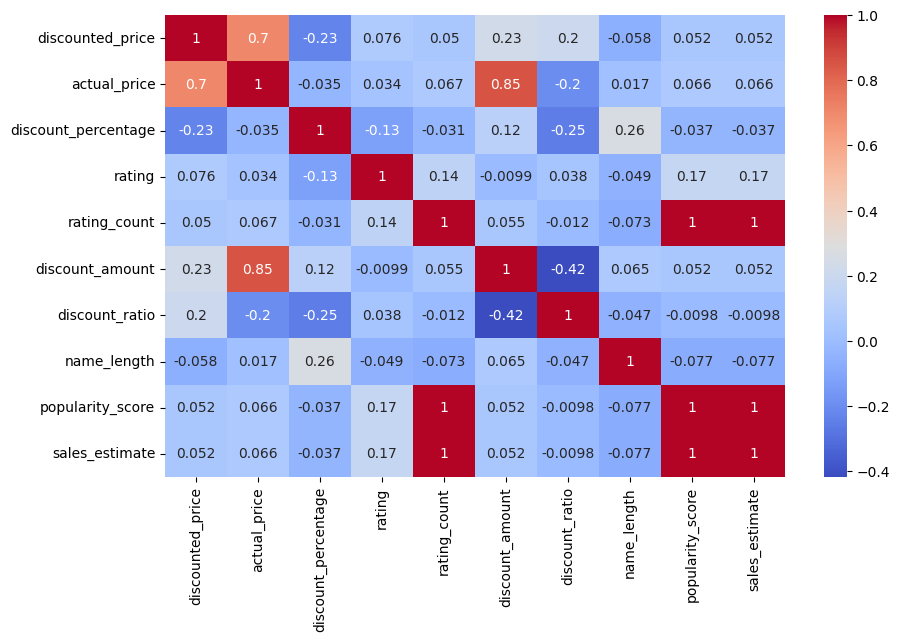

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
drop_cols = ['discount_percentage','discount_amount','discount_ratio']
df_model = df.drop(columns=drop_cols)

In [ ]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

      Actual   Predicted
0   13275.60   13287.317
1    2264.40    2289.418
2      75.90      86.822
3   20098.20   20178.576
4   51999.90   52552.905
5  134508.70  134508.700
6  134508.70  134508.700
7   22006.75   22006.750
8    1096.50    1050.218
9   19323.00   19322.433


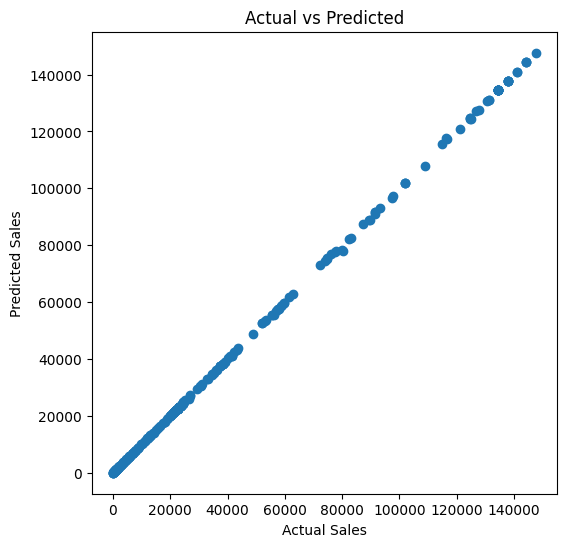

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
new_data = pd.DataFrame({
    'actual_price': [1500],
    'rating': [4.2],
    'rating_count': [120],
    'main_category': ['Electronics'],
    'brand': ['Samsung'],
    'price_bucket': ['Medium']
})

In [ ]:
new_data = pd.get_dummies(new_data)

# Align columns with training data
new_data = new_data.reindex(columns=X.columns, fill_value=0)

In [ ]:
prediction = best_model.predict(new_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 211.6509999999996


In [ ]:
comparison.head()

,Actual,Predicted
0,13275.6,13287.317
1,2264.4,2289.418
2,75.9,86.822
3,20098.2,20178.576
4,51999.9,52552.905


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
df['predicted_sales'] = model.predict(X)

In [ ]:
top_10 = df.sort_values(by='predicted_sales', ascending=False).head(10)

In [ ]:
top_10[['brand','main_category','actual_price','rating','predicted_sales']]

,brand,main_category,actual_price,rating,predicted_sales
1145,Swiffer,Home&Kitchen,1999.0,4.8,153339.918
820,Redgear,Computers&Accessories,550.0,4.6,149763.955
815,Seagate,Computers&Accessories,1650.0,4.5,148189.219
864,SanDisk,Electronics,1800.0,4.5,147992.377
810,Crucial,Computers&Accessories,3100.0,4.5,147959.570
734,Fire-Boltt,Computers&Accessories,995.0,4.5,147828.342
30,AmazonBasics,Computers&Accessories,1650.0,4.5,147828.342
40,AmazonBasics,Computers&Accessories,695.0,4.5,147795.535
212,AmazonBasics,Computers&Accessories,800.0,4.5,147664.307
204,BlueRigger,Electronics,599.0,4.4,144383.607


#Recommendation System

In [ ]:
features=[
    'actual_price',
    'rating',
    'main_category',
    'brand',
    'price_bucket'
]


In [ ]:
df['combined_features'] = (
    df['main_category'].astype(str) + " " +
    df['sub_category'].astype(str) + " " +
    df['brand'].astype(str) + " " +
    df['price_bucket'].astype(str) + " " +
    df['rating'].astype(str)
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
matrix = tfidf.fit_transform(df['combined_features'])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix)

In [ ]:
def recommend_products(product_index, top_n=5):
    scores = list(enumerate(similarity[product_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top_products = scores[1:top_n+1]

    product_indices = [i[0] for i in top_products]

    return df.iloc[product_indices][
        ['brand','main_category','actual_price','rating']
    ]

In [ ]:
recommend_products(10)

,brand,main_category,actual_price,rating
10,Portronics,Computers&Accessories,339.0,4.3
59,Portronics,Computers&Accessories,1650.0,4.3
393,Portronics,Computers&Accessories,399.0,4.2
428,Portronics,Computers&Accessories,339.0,4.3
438,Portronics,Computers&Accessories,699.0,4.1


In [ ]:
def recommend_products(product_index, top_n=5):
    scores = list(enumerate(similarity[product_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top_indices = [i[0] for i in scores[1:top_n+1]]

    recommendations = df.iloc[top_indices]

    # remove duplicate brands
    recommendations = recommendations.drop_duplicates(subset=['brand'])

    return recommendations[['brand','main_category','actual_price','rating']]

In [ ]:
features = [
    'main_category',
    'sub_category',
    'price_bucket',
    'rating'
]

In [ ]:
df.drop_duplicates(subset=['brand','actual_price','rating'], inplace=True)

In [ ]:
recommendations = df.iloc[top_indices]

recommendations = recommendations.drop_duplicates(subset=['brand'])

NameError: name 'top_indices' is not defined

In [ ]:
def smart_recommend(product_index, top_n=5):
    scores = list(enumerate(similarity[product_index]))

    scored_products = []

    for i, sim_score in scores:
        final_score = (0.7 * sim_score) + (0.3 * df.loc[i, 'predicted_sales'])
        scored_products.append((i, final_score))

    scored_products = sorted(scored_products, key=lambda x: x[1], reverse=True)

    top_indices = [i[0] for i in scored_products[1:top_n+1]]

    return df.iloc[top_indices][
        ['brand','main_category','actual_price','rating','predicted_sales']
    ]

In [ ]:
smart_recommend(10)

,brand,main_category,actual_price,rating,predicted_sales
820,Redgear,Computers&Accessories,550.0,4.6,149763.955
815,Seagate,Computers&Accessories,1650.0,4.5,148189.219
864,SanDisk,Electronics,1800.0,4.5,147992.377
810,Crucial,Computers&Accessories,3100.0,4.5,147959.570
30,AmazonBasics,Computers&Accessories,1650.0,4.5,147828.342


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']